In [1]:
import os
import scvi
import scanpy as sc
import anndata as ad
import numpy as np
from scContextVI import scContextVIModel
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

scvi.settings.seed = 42

Seed set to 42


In [2]:
adata = sc.read("data/ifnb_preprocess.h5ad")
adata = adata[adata.obs['cell'].notna()].copy()
adata.X = adata.X.toarray()

sc.pp.filter_cells(adata, min_genes=50)
sc.pp.filter_genes(adata, min_cells=100)
adata.layers['counts'] = adata.X.copy()
adata.var_names = adata.var['V2'].astype(str)

sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
    n_top_genes=2500,
    layer='counts',
    subset=True,
)

In [6]:
condition_key = 'stim'
group_key = 'cell'
stratify_labels = (
    adata.obs[group_key].astype(str) + "_" + 
    adata.obs[condition_key].astype(str)
)
print("Unique groups for stratification:", len(stratify_labels.unique()))

indices = np.arange(adata.n_obs)

train_val_idx, test_idx = train_test_split(
    indices, 
    test_size=0.1, 
    stratify=stratify_labels,
    random_state=42
)

adata_train = adata[train_val_idx].copy()
adata_test = adata[test_idx].copy()

print(f"Total cells: {adata.n_obs}")
print(f"Train set size: {adata_train.n_obs}")
print(f"Test set size: {adata_test.n_obs}")

Unique groups for stratification: 16


Total cells: 24645
Train set size: 22180
Test set size: 2465


In [7]:
control_key='ctrl'
conditions = ['ctrl', 'stim',]

group_indices_list = [np.where(adata_train.obs[condition_key] == group)[0] 
                      for group in conditions
                      ]

scContextVIModel.setup_anndata(adata_train, 
                              condition_key=condition_key, 
                              layer='counts')

condition2int = adata_train.obs.groupby(condition_key, 
                                        observed=False)['_scvi_condition'].first().to_dict()

In [8]:
model = scContextVIModel(
    adata_train,
    condition2int=condition2int,
    control=control_key,
    n_background_latent=10,
    n_te_latent=10,
    n_layers=2,
    n_hidden=128,
    use_mmd=True,
    use_consistency=True,
    mmd_weight=10,
    norm_weight=0.5,
)

In [ ]:
model.train(
    group_indices_list,
    max_epochs=300,  
    accelerator="gpu",
    devices=[2],
    train_size=0.9,
    batch_size=32,
    early_stopping=True,
    datasplitter_kwargs={"num_workers": 4},
    plan_kwargs={"lr": 1e-3},
)

In [10]:
save_dir = "models/IID_nologpre"  # IID_nologpre
# model.save(save_dir, overwrite=True, save_anndata=False)
# print("Finished")

model = model.load(save_dir, 
                   adata=adata, 
                   accelerator="gpu", 
                   device=[3])

INFO     File models/IID_nologpre/model.pt already downloaded                                                      


/home/sxl/miniconda3/envs/torch2.5/lib/python3.11/site-packages/scvi/model/base/_base_model.py:849: UserWarning: `var_names` for the loaded `model` does not match those used to train the model. For valid results, the former should match the latter.
  _validate_var_names(adata, var_names)


In [11]:
adata_simulate = adata_test[adata_test.obs[condition_key] == 'stim'].copy()
adata_simulate.obs['is_real'] = 'Real stim'

adata_ctrl = adata_test[adata_test.obs[condition_key]=='ctrl'].copy()
ctrl2stim = model.get_count_expression_cross_condition(
    adata=adata_ctrl,
    source_condition='ctrl',
    target_condition='stim',
)
ctrl2stim.obs['is_real'] = 'Ctrl -> stim'

adata_ctrl2stim = ad.concat([adata_simulate, ctrl2stim])
sc.pp.normalize_total(adata_ctrl2stim, target_sum=1e4)
sc.pp.log1p(adata_ctrl2stim)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


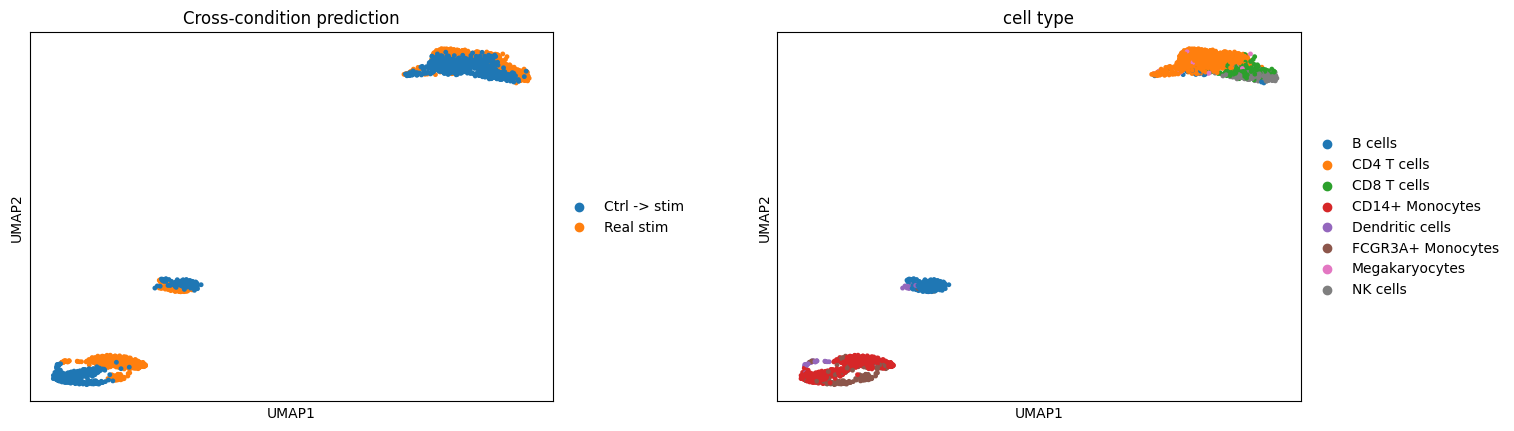

In [12]:
sc.pp.pca(adata_ctrl2stim)
sc.pp.neighbors(adata_ctrl2stim)
sc.tl.umap(adata_ctrl2stim)

sc.pl.umap(
    adata_ctrl2stim,
    color = ['is_real', group_key],
    title = ['Cross-condition prediction', 'cell type'],
    wspace=0.3
)

In [13]:
from evaluate import evaluate_adata

ctrl2stim.obs[condition_key] = 'predicted'

eval_data = ad.concat([adata_ctrl, adata_simulate, ctrl2stim])

sc.pp.normalize_total(eval_data, target_sum=1e4)
sc.pp.log1p(eval_data)

key_dic = {'condition_key': 'stim',
           'cell_type_key': 'cell',
           'ctrl_key': 'ctrl',
           'stim_key': 'stim',
           'pred_key': 'predicted',
           }

metrics = evaluate_adata(eval_data, key_dic)
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

/home/sxl/miniconda3/envs/torch2.5/lib/python3.11/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Mse: 0.4412
Common DEGs: 84.0000
Wasserstein: 0.3928
KL: 0.3003
